# 最適化結果（bax 出力）のパフォーマンス評価

`alphaeval.bax` を使って、最適化システム bax の出力ディレクトリ（`bax/output/{version}`）を評価する手順をまとめる。
この Notebook は先頭セルのパラメータ（出力ディレクトリ、ベンチマーク名、税率区分など）を変えれば、別の最適化結果にもそのまま使える。

## 入力

| ファイル | 内容 | 本 Notebook での用途 |
| --- | --- | --- |
| `st_prfm.dat` | BM / ファンド / 超過リターン（取引コスト控除後）、取引コスト、回転率の月次系列 | パフォーマンス指標の主データ |
| `st_objv.dat`, `S{date}.dat` | 効用、ポートフォリオのアルファスコア、推定 TE（`omega`）、取引コスト | 推定 TE と実現 TE の比較、アルファ水準 |
| `O{date}.dat` | 最適化前後のウェイト、BM ウェイト、アルファ、銘柄別上下限（非保有の BM 銘柄は載らない） | 保有統計、制約への張り付き、アルファ実現度、税評価のウェイト |
| `me_{date}.dat` | 前月末のアクティブウェイトと当月の配当込みリターン（BM のみ保有の銘柄も含む） | 銘柄・業種別の寄与、アクティブシェア |
| `A{date}.dat` | リスクインデックス・業種・国・通貨のエクスポージャー（`opt` / `bm` / `init` / `opt_active`） | ファクター・業種ティルトの確認 |
| `op_{date}.dat` | 最適化後の株数・株価・NAV | （参考）ウェイトの再計算 |
| `bc.txt` | 実行パラメータ | 制約の上下限（`cs_*_default`）の取得 |

`alphaeval.bax` の規約: ウェイト・リターン・回転率・コスト・`omega` はすべて **小数** に変換して返す（ファイルは %）。
ファンドのリターンはニューメレール（`bc.txt` の `numeraire`、本例は USD）建て。

確認済みの関係: `me` の `prev_awgt` = 前月 `O` の `wgt_o − wgt_b`、`fund_ex_rtn = Σ prev_awgt × rtn − tr_cost`、`fund_rtn = bm_rtn + fund_ex_rtn`。

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import numpy as np
import pandas as pd

from alphaeval import InputStore, india_tax_schedule, performance_summary, portfolio_returns, quantile_analysis
from alphaeval.bax import BaxOutput, after_tax, evaluate_bax, group_contribution

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3})

# ---- パラメータ
BAX_DIR = "../bax/output/v0"                  # 評価する最適化出力
INPUT_ROOT = "../input/msci_india_imi"        # 業種マップ・現地通貨リターン・参照戦略に使う
SCORE_USED = "composite/comp_ew"              # この最適化で使ったアルファ（参照戦略の比較用）
BENCHMARK = "msci_india"
RISK_MODEL = "GEMLT"
FPI_TYPE = "trust"                            # 税率区分: "trust"（信託扱い）/ "company"（外国法人扱い）
TE_WINDOW = 36
BURN_IN = 12
SPLIT = "2019-01-01"                          # 参考: 合成スコアの IS/OOS 境界
SECTOR_NAMES = {10: "エネルギー", 15: "素材", 20: "資本財", 25: "一般消費財", 30: "生活必需品", 35: "ヘルスケア", 40: "金融", 45: "情報技術", 50: "通信", 55: "公益", 60: "不動産"}

out = BaxOutput(BAX_DIR)
store = InputStore(INPUT_ROOT)
print(f"リバランス日: {out.rebalance_dates.min().date()} 〜 {out.rebalance_dates.max().date()} ({len(out.rebalance_dates)} 回)")
print({k: out.params.get(k) for k in ["numeraire", "target_omega", "cs_rot", "cs_owgt_default", "cs_a_owgt_default", "cs_rskidx_default", "cs_industry_default", "coef_horiz", "rskmdl_name"]})

リバランス日: 2011-01-31 〜 2026-03-31 (183 回)
{'numeraire': 'USA', 'target_omega': '5', 'cs_rot': '0.15', 'cs_owgt_default': '0,0.1', 'cs_a_owgt_default': '-0.03,0.03', 'cs_rskidx_default': '-2,2', 'cs_industry_default': '-0.03,0.03', 'coef_horiz': '12', 'rskmdl_name': 'barra_gemlt'}


## 0. 最適化条件の確認

`bc.txt` から NAV と制約条件を抜き出して確認する。`settings()` は主要な条件を解釈付きで、
`describe_params()` は全パラメータを既定値との差分付きで返す（説明はパラメータ説明書に基づく）。
`fn_dyn_bc` が指定されている場合は日付ごとの上書きがあり得るので、別途その内容も確認すること。

In [2]:
pd.set_option("display.max_colwidth", 80)
settings = out.settings()
print(f"最初の op ファイルの NAV: {out.initial_nav():,.0f}（前回リバランス時 NAV に当月パフォーマンスを反映した値）")
display(settings.set_index("item"))

最初の op ファイルの NAV: 100,000,000（前回リバランス時 NAV に当月パフォーマンスを反映した値）


,value,interpretation,parameter
item,,,
初期 NAV,"100,000,000 USA",fn_init_fund の -n$2 = 100（百万単位）→ 現金 100 百万で開始,fn_init_fund / fn_abbr2
NAV の扱い,1,毎回リバランス時に NAV を初期値へリセット（一定 NAV）,f_same_nav
初期ポートフォリオ,`$I/create_pf_cash -C $N -n$2`,現金 100% から開始,fn_init_fund
ターゲット TE（omega）,5,推定 TE ≤ 5%（年率）,target_omega
リスク回避度,0,効用 = α − λ·TE² の λ（0: 効用にリスク項なし、TE 制約のみ）,coef_rskavr
リスクモデル,barra_gemlt,共分散: ファクターモデル,rskmdl_name / covtype
個別銘柄ウェイト,"0,0.1",0% 〜 10%,cs_owgt_default
個別銘柄アクティブウェイト,"-0.03,0.03",対 BM -3% 〜 3%,cs_a_owgt_default
キャッシュ制約,0,キャッシュウェイトの制約値,cs_cash_wgt


既定値から変更されているパラメータ（入出力パスを除く）。

In [3]:
desc = out.describe_params()
changed = desc[(desc["is_default"] == False) & (~desc["category"].isin(["io", "unknown"]))]  # noqa: E712
display(changed.set_index("parameter")[["category", "value", "default", "description"]])

,category,value,default,description
parameter,,,,
numeraire,backtest,USA,NONE,基軸通貨（gbax のみ）
date_from,backtest,201101,200312,バックテスト開始日（YYYYMM / YYYYMMDD、-1: 前月末、0: 前営業日）
date_to,backtest,202603,-1,バックテスト終了日
fn_init_bm,backtest,`$I/create_pf_cash -C $N`,NONE,開始時のベンチマークファイル（`create_pf_cash -C $N` は現金）
fn_init_fund,backtest,`$I/create_pf_cash -C $N -n$2`,NONE,開始時のポートフォリオファイル（`create_pf_cash -C $N -n$2` は現金 $2 百万）
coef_rskavr,risk,0,0.1,リスク回避度（効用 = α − λ·TE² の λ）
target_omega,risk,5,NONE,ターゲット TE（年率 %）。正: 上限制約、負: 下限制約
f_only_unv,weight,1,0,保有をユニバースに限定するか。1: 限定（ユニバース外は強制売却）
cs_owgt_default,weight,"0,0.1","0,1","個別銘柄の保有ウェイト制約（min,max、小数）"


## 1. 一括評価

`evaluate_bax` で月次表・要約・年別表・エクスポージャー統計・保有統計・寄与・アルファ実現度をまとめて計算する。
業種マップ（`attributes/gics` の先頭 2 桁）は時点依存の `DataFrame` で渡す。

In [4]:
gics = store.alpha("attributes/gics")
sector = (gics // 1_000_000).reindex(index=out.rebalance_dates)
sector_named = sector.apply(lambda col: col.map(SECTOR_NAMES))

res = evaluate_bax(out, mapping=sector_named, te_window=TE_WINDOW)
display(res.summary.to_frame("value").round(4))

,value
ann_return_fund,0.1156
ann_return_bm,0.0541
active_return,0.0575
active_return_geo,0.0615
active_return_gross,0.0674
tracking_error,0.0623
information_ratio,0.9228
omega_mean,0.0494
te_ratio_realized_to_omega,1.2604
cost_drag,0.0099


| 指標 | 意味 |
| --- | --- |
| `active_return` / `active_return_gross` | 超過リターンの年率算術平均（取引コスト控除後 / 控除前） |
| `tracking_error` / `omega_mean` / `te_ratio_realized_to_omega` | 実現 TE（年率）/ 最適化時の推定 TE の平均 / その比 |
| `information_ratio` | `active_return / tracking_error` |
| `cost_drag` | 取引コスト（年率） |
| `turnover_annual` | 片道回転率（年率） |
| `active_share_mean` | アクティブシェア（`me` ベース。BM のみ保有の銘柄を含む正しい値） |
| `max_drawdown_excess` | 超過リターン累積の最大ドローダウン |

## 2. 累積リターンと年別

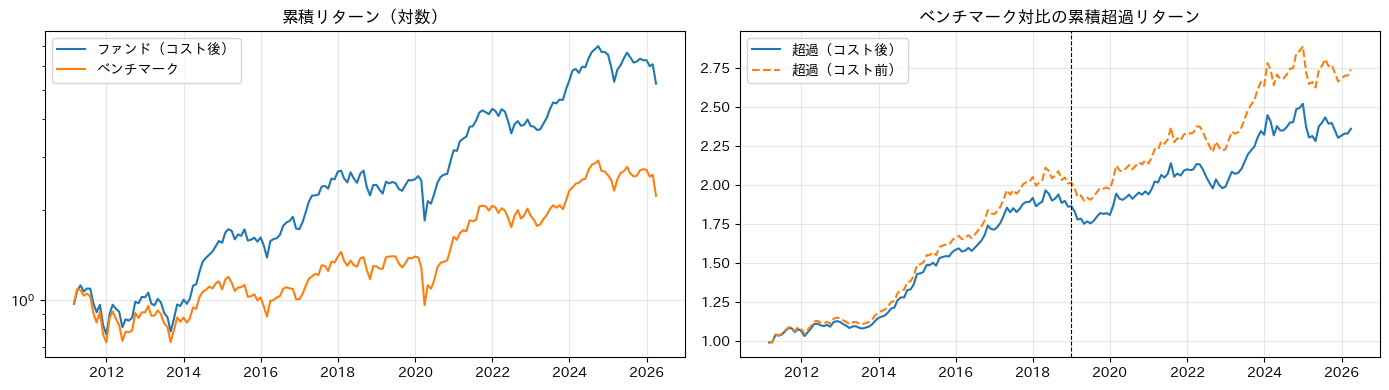

,bm,fund,excess,excess_arith,tr_cost,turnover,te,n_months
2011,-0.277,-0.232,0.045,0.056,0.012,1.046,0.069,11
2012,0.260,0.330,0.070,0.045,0.009,0.885,0.065,12
2013,-0.039,-0.017,0.022,0.026,0.010,0.848,0.041,12
2014,0.241,0.546,0.305,0.224,0.009,0.929,0.054,12
2015,-0.061,0.042,0.102,0.104,0.009,0.946,0.045,12
2016,-0.014,0.066,0.080,0.082,0.008,0.971,0.051,12
2017,0.390,0.555,0.166,0.117,0.011,1.260,0.049,12
2018,-0.072,-0.098,-0.026,-0.025,0.010,1.187,0.071,12
2019,0.078,0.045,-0.032,-0.029,0.010,1.011,0.048,12
2020,0.163,0.248,0.085,0.072,0.010,0.916,0.059,12


In [5]:
t = res.table.dropna(subset=["fund"])
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(t.index, (1 + t["fund"]).cumprod(), label="ファンド（コスト後）")
axes[0].plot(t.index, (1 + t["bm"]).cumprod(), label="ベンチマーク")
axes[0].set_yscale("log")
axes[0].set_title("累積リターン（対数）")
axes[0].legend()
rel = (1 + t["fund"]).cumprod() / (1 + t["bm"]).cumprod()
axes[1].plot(t.index, rel, label="超過（コスト後）")
axes[1].plot(t.index, (1 + t["excess_gross"]).cumprod() / (1 + t["excess"]).cumprod() * rel, linestyle="--", label="超過（コスト前）")
axes[1].axvline(pd.Timestamp(SPLIT), color="k", linestyle="--", linewidth=0.8)
axes[1].set_title("ベンチマーク対比の累積超過リターン")
axes[1].legend()
plt.tight_layout()
plt.show()
display(res.yearly.round(3))

## 3. 実現 TE と推定 TE

`omega` は最適化時点のリスクモデルによる推定 TE（年率）。実現 TE との比が 1 を大きく超えるなら、
リスクモデルが捉えていないリスク（アルファに相関した固有リスクなど）を取っている。

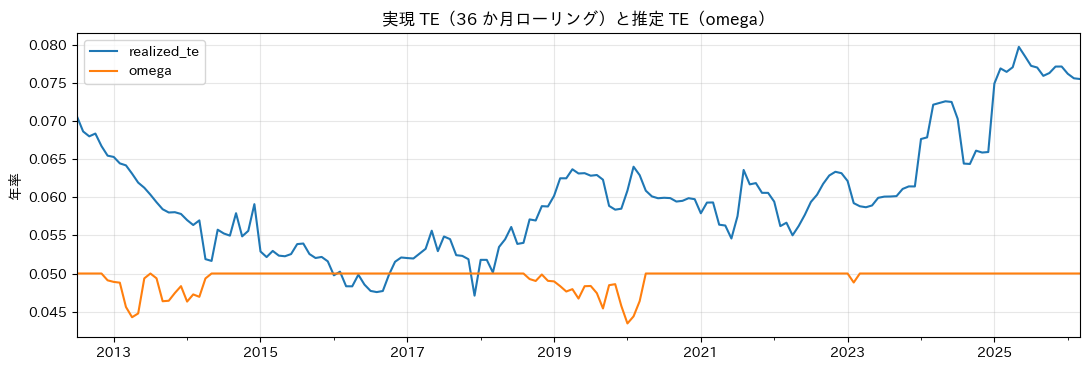

実現 TE / 推定 TE: 全期間 1.26、直近 1.51


In [6]:
rt = res.rolling_te.dropna()
ax = rt[["realized_te", "omega"]].plot(figsize=(11, 3.8))
ax.set_title(f"実現 TE（{TE_WINDOW} か月ローリング）と推定 TE（omega）")
ax.set_ylabel("年率")
plt.tight_layout()
plt.show()
print(f"実現 TE / 推定 TE: 全期間 {res.summary['te_ratio_realized_to_omega']:.2f}、直近 {rt['ratio'].iloc[-1]:.2f}")

## 4. エクスポージャー

リスクインデックスと業種のアクティブエクスポージャー。`at_lower` / `at_upper` は制約（`bc.txt` の `cs_*_default`）に
張り付いた月の割合。張り付きが多い制約はポートフォリオ構築を実質的に決めている。

リスクインデックス（|平均| 上位）


,mean,std,min,max,abs_mean,at_lower,at_upper
R16_SIZE,-0.981,0.133,-1.243,-0.631,0.981,0.0,0.0
R13_MOMENTUM,0.471,0.182,0.127,0.881,0.471,0.0,0.0
R14_PROFIT,0.358,0.200,0.046,0.876,0.358,0.0,0.0
R09_LEVERAGE,-0.290,0.133,-0.600,-0.018,0.290,0.0,0.0
R12_MIDCAP,0.287,0.145,-0.062,0.544,0.290,0.0,0.0
R08_INVSQLTY,0.231,0.106,-0.060,0.432,0.233,0.0,0.0
R03_DIVYILD,0.210,0.096,0.005,0.441,0.210,0.0,0.0
R15_RESVOL,0.178,0.177,-0.185,0.535,0.202,0.0,0.0


業種（|平均| 上位）


,mean,std,min,max,abs_mean,at_lower,at_upper
I05_BANKS,-0.029,0.003,-0.03,-0.007,0.029,0.727,0.000
I27_SOFTWARE,-0.023,0.010,-0.03,0.009,0.024,0.508,0.000
I12_CONSTPP,-0.015,0.014,-0.03,0.030,0.019,0.109,0.049
I32_PHARMA,-0.004,0.021,-0.03,0.030,0.019,0.142,0.071
I04_AUTOCOMP,-0.013,0.018,-0.03,0.030,0.019,0.230,0.022
I28_MACHINRY,0.016,0.015,-0.03,0.030,0.019,0.011,0.262
I13_CONSDUR,0.017,0.013,-0.01,0.030,0.018,0.000,0.219
I15_DIVFIN,-0.009,0.019,-0.03,0.030,0.018,0.257,0.027


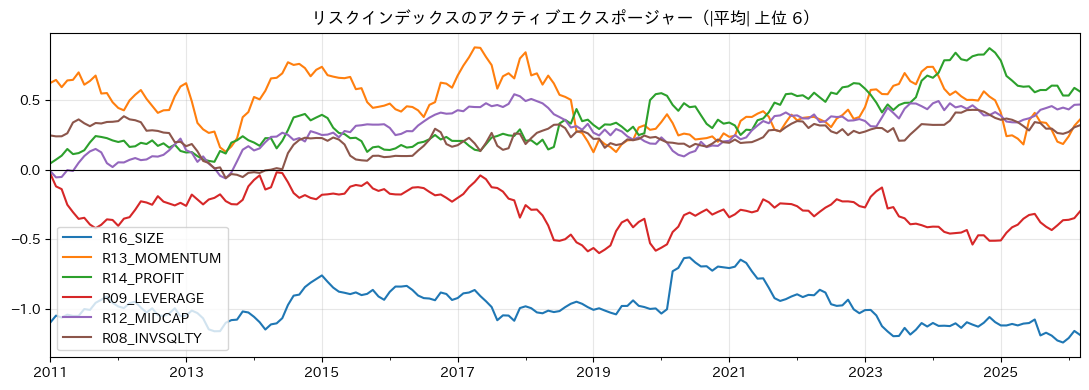

In [7]:
print("リスクインデックス（|平均| 上位）")
display(res.exposures["risk_index"].head(8).round(3))
print("業種（|平均| 上位）")
display(res.exposures["industry"].head(8).round(3))

ri = out.exposure_panel("opt_active", "risk_index")
top = res.exposures["risk_index"].index[:6]
ax = ri[top].plot(figsize=(11, 4))
ax.axhline(0, color="k", linewidth=0.8)
ax.set_title("リスクインデックスのアクティブエクスポージャー（|平均| 上位 6）")
plt.tight_layout()
plt.show()

## 4b. リスクモデルによる分解: Style / Industry / Country / Currency / Market / Specific

`A` ファイルのアクティブエクスポージャー（接頭辞 R = Style、I = Industry、C = Country、c = Currency、`C89_WORLD` = Market）を
`risk_models/{RISK_MODEL}/factor_list.csv` のファクター ID に対応付け、

- **超過リターンの分解**: 前月末のアクティブエクスポージャー × 当月のファクターリターンをグループ別に合計し、残差を Specific とする
- **推定リスクの分解**: $x'Fx$ をグループ別の寄与（相互項を含む）に分け、$\omega^2 - x'Fx$ を Specific とする

の 2 つを計算する。

超過リターン（コスト前）の分解: 年率寄与


,年率寄与,年率リスク寄与（月次 std × √12）,月次勝率
Style,0.0175,0.0251,0.5847
Industry,0.0037,0.0080,0.5792
Country,0.0007,0.0113,0.5519
Currency,0.0000,0.0000,0.0000
Market,0.0000,0.0000,0.0000
factor_total,0.0219,0.0292,0.6448
specific,0.0468,0.0567,0.6230
excess_gross,0.0674,0.0623,0.6612


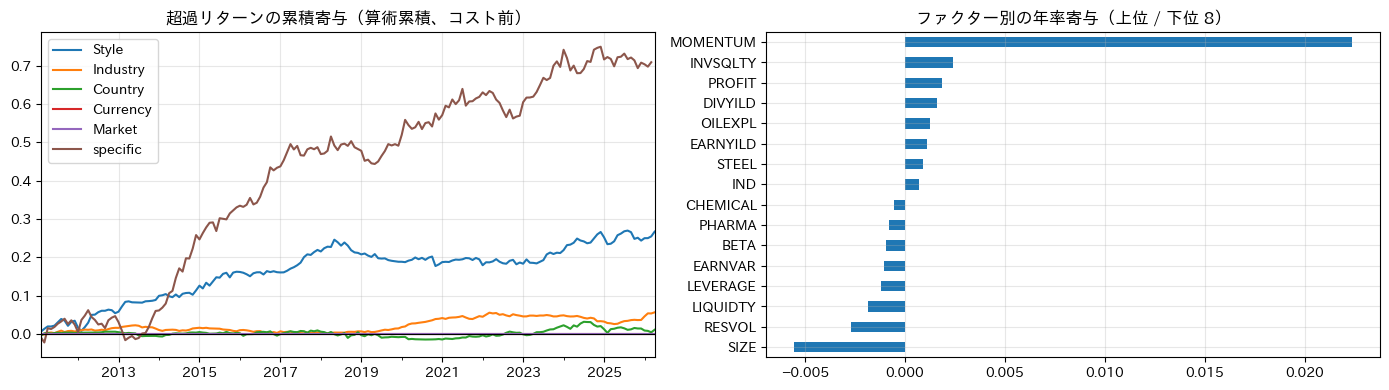

In [8]:
from alphaeval.bax import factor_attribution, risk_decomposition

factor_list = store.factor_list(RISK_MODEL)
factor_returns = store.factor_return(RISK_MODEL)
groups, per_factor = factor_attribution(out, factor_returns, factor_list)

ann = groups.mean() * 12
print("超過リターン（コスト前）の分解: 年率寄与")
display(pd.DataFrame({"年率寄与": ann, "年率リスク寄与（月次 std × √12）": groups.std() * np.sqrt(12), "月次勝率": (groups > 0).mean()}).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
cum = groups[[c for c in ["Style", "Industry", "Country", "Currency", "Market", "specific"] if c in groups]].cumsum()
cum.plot(ax=axes[0])
axes[0].axhline(0, color="k", linewidth=0.8)
axes[0].set_title("超過リターンの累積寄与（算術累積、コスト前）")
top = per_factor.mean().mul(12).sort_values()
pd.concat([top.head(8), top.tail(8)]).rename(index=factor_list.set_index("id")["symbol"]).plot.barh(ax=axes[1])
axes[1].set_title("ファクター別の年率寄与（上位 / 下位 8）")
plt.tight_layout()
plt.show()

推定アクティブリスク（omega）の分解: 平均


,分散シェア（平均）
Country,0.039
Currency,0.000
Industry,0.019
Market,0.000
Style,0.281
specific,0.661


,mean,min,max
omega,0.0494,0.0435,0.0500
te_factor,0.0286,0.0207,0.0361
te_specific,0.0401,0.0346,0.0447


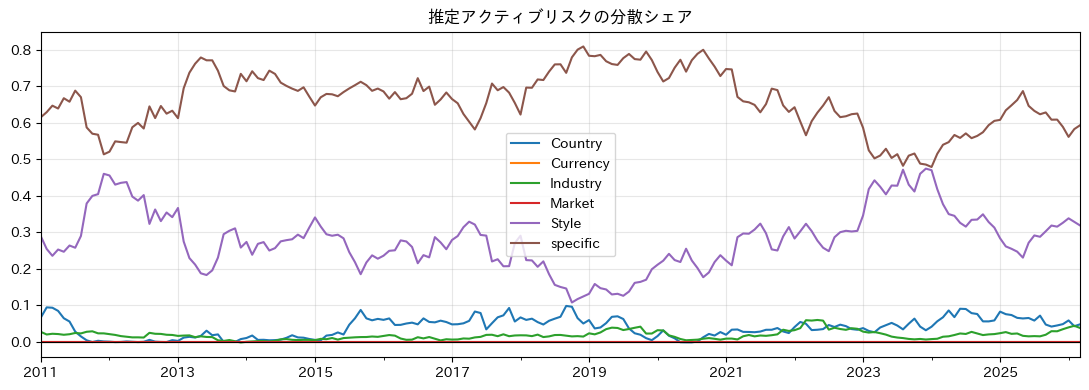

In [9]:
rd = risk_decomposition(out, lambda d: store.factor_covariance(RISK_MODEL, d), factor_list)
share_cols = [c for c in rd.columns if c.startswith("share_")]
print("推定アクティブリスク（omega）の分解: 平均")
display(pd.DataFrame({"分散シェア（平均）": rd[share_cols].mean().rename(lambda c: c.replace("share_", "")), }).round(3))
display(rd[["omega", "te_factor", "te_specific"]].describe().round(4).T[["mean", "min", "max"]])

ax = rd[share_cols].rename(columns=lambda c: c.replace("share_", "")).plot(figsize=(11, 4))
ax.axhline(0, color="k", linewidth=0.8)
ax.set_title("推定アクティブリスクの分散シェア")
plt.tight_layout()
plt.show()

実現した超過リターンの分散も同じグループで見ると、事前のリスク配分（上図）と事後の寄与（下表）の対応が確認できる。
`Specific` の実現寄与が大きいのは、アルファがファクターに還元されない銘柄固有の情報を持っていることを意味する。

In [10]:
realized = groups.drop(columns=["factor_total", "excess_gross"])
cov_r = realized.cov() * 12
total_var = realized.sum(axis=1).var() * 12
display(pd.DataFrame({"実現分散寄与（共分散込み）": cov_r.sum(axis=1), "シェア": cov_r.sum(axis=1) / total_var, "事前シェア（平均）": rd[share_cols].mean().rename(lambda c: c.replace("share_", "")).reindex(cov_r.index)}).round(4))

,実現分散寄与（共分散込み）,シェア,事前シェア（平均）
Style,0.0005,0.1176,0.2811
Industry,0.0001,0.0186,0.0186
Country,0.0002,0.0622,0.0393
Currency,0.0000,0.0000,0.0000
Market,0.0000,0.0000,0.0000
specific,0.0031,0.8083,0.6610


## 5. 保有統計

銘柄数、アクティブシェア、上位集中、個別上下限への張り付き。
`active_share_file` は `O` ファイルに載る銘柄だけで計算した参考値で、BM のみ保有の銘柄が抜けるため過小になる
（正しい値は要約の `active_share_mean`）。

,mean,min,max
n_hold,86.880,55.000,120.000
n_bm_in_file,24.880,11.000,46.000
max_weight,0.071,0.038,0.100
top10_weight,0.424,0.303,0.550
active_share_file,0.427,0.314,0.500
n_at_upper,4.033,0.000,10.000
n_at_lower,3.585,0.000,6.000
alpha_weighted,1.021,0.670,1.286
alpha_bm_weighted,0.067,-0.410,0.529


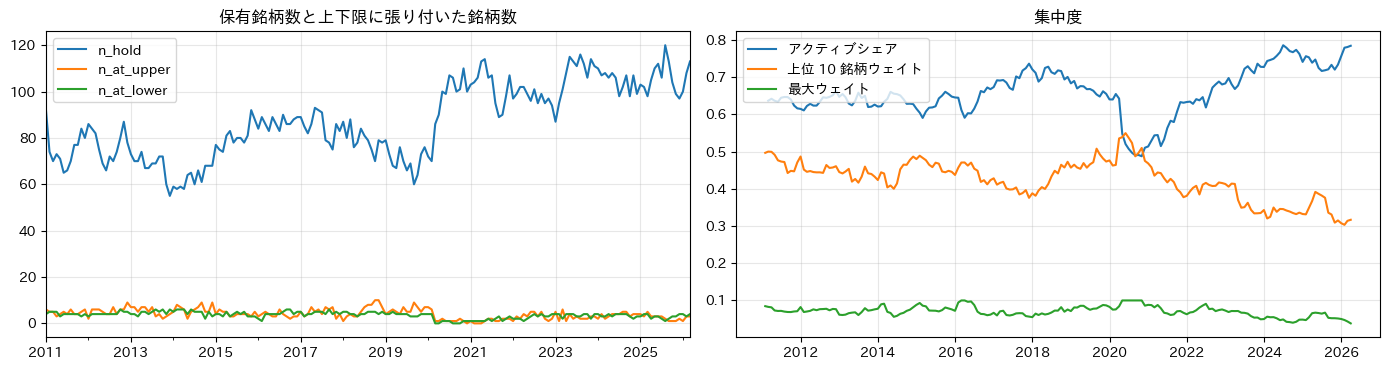

In [11]:
h = res.holdings
display(h.describe().round(3).T[["mean", "min", "max"]])
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
h[["n_hold", "n_at_upper", "n_at_lower"]].plot(ax=axes[0])
axes[0].set_title("保有銘柄数と上下限に張り付いた銘柄数")
axes[1].plot(res.table.index, res.table["active_share"], label="アクティブシェア")
axes[1].plot(h.index, h["top10_weight"], label="上位 10 銘柄ウェイト")
axes[1].plot(h.index, h["max_weight"], label="最大ウェイト")
axes[1].set_title("集中度")
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. 寄与分析

`Σ_t prev_awgt × rtn`（取引コスト控除前）を銘柄・業種で集計する。業種は前月末の GICS セクター。

寄与 上位 / 下位 5 銘柄（累積、コスト前）


,contribution,months_active,mean_active_weight,mean_return
INDDVM1,0.0729,135,0.0121,0.0240
INDADR1,0.0630,183,0.0027,0.0194
INDDMD1,0.0490,78,0.0159,0.0302
INDEGY1,0.0422,32,0.0146,0.0787
INDBY01,0.0402,114,0.0123,0.0250
INDAAC2,-0.0400,124,-0.0143,0.0284
INDABG1,-0.0444,183,-0.0209,0.0140
INDAGI1,-0.0479,150,-0.0278,0.0131
INDBOT1,-0.0485,183,-0.0209,0.0150
INDABV1,-0.0752,183,-0.0305,0.0139


,contribution,contribution_annual,mean_active_weight,te_contribution
金融,0.3570,0.0234,-0.0184,0.0288
一般消費財,0.2558,0.0168,0.0287,0.0208
ヘルスケア,0.1502,0.0099,0.0116,0.0171
資本財,0.1202,0.0079,0.0305,0.0166
生活必需品,0.0561,0.0037,-0.0075,0.0095
公益,0.0467,0.0031,-0.0012,0.0115
素材,0.0409,0.0027,0.0081,0.0169
通信,0.0402,0.0026,0.0029,0.0105
情報技術,0.0266,0.0017,-0.0198,0.0141
不動産,0.0125,0.0008,0.0009,0.0029


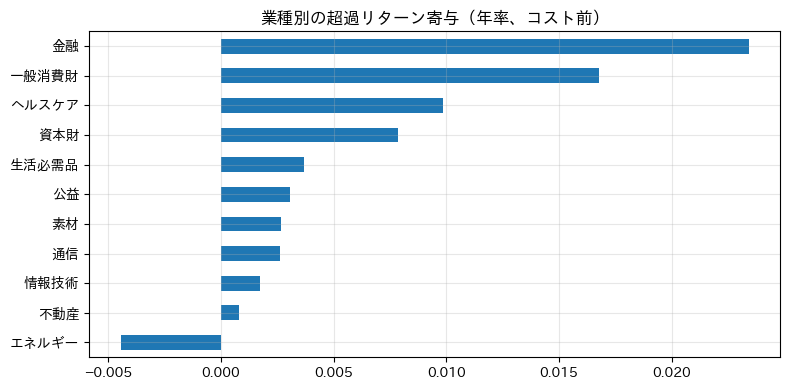

In [12]:
print("寄与 上位 / 下位 5 銘柄（累積、コスト前）")
display(pd.concat([res.contributions.head(5), res.contributions.tail(5)]).round(4))
gc = res.group_contributions
display(gc.round(4))
ax = gc["contribution_annual"].sort_values().plot.barh(figsize=(8, 4))
ax.set_title("業種別の超過リターン寄与（年率、コスト前）")
plt.tight_layout()
plt.show()

## 7. アルファの実現度

最適化に渡したアルファスコア（`O` の `alpha`）と翌月リターンの順位相関。`O` に載る銘柄（保有 + BM 保有）の中での値なので
ユニバース全体の IC とは異なるが、「選んだ集合の中で順位が当たっているか」の目安になる。

平均 0.0284、ICIR 0.201、t 値 2.72、勝率 57.9%、n 183


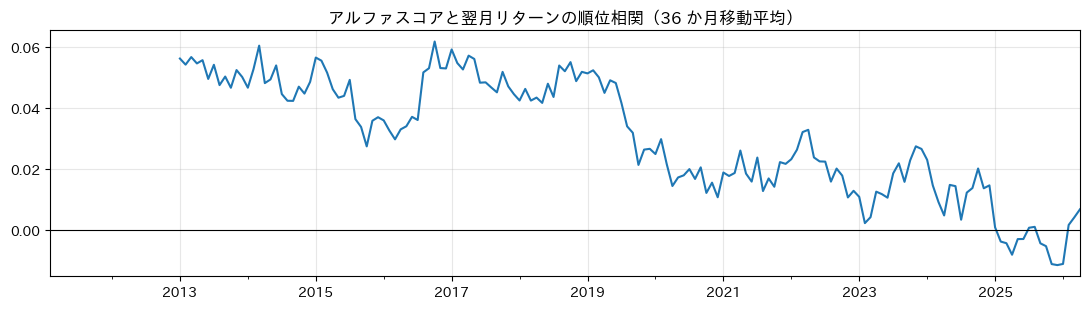

In [13]:
ic = res.alpha_ic
print(f"平均 {ic.mean():.4f}、ICIR {ic.mean() / ic.std():.3f}、t 値 {ic.mean() / ic.std() * np.sqrt(len(ic)):.2f}、勝率 {(ic > 0).mean():.1%}、n {len(ic)}")
ax = ic.rolling(36, min_periods=24).mean().plot(figsize=(11, 3.2))
ax.axhline(0, color="k", linewidth=0.8)
ax.set_title("アルファスコアと翌月リターンの順位相関（36 か月移動平均）")
plt.tight_layout()
plt.show()

## 8. 税控除後評価

最適化後ウェイト（`wgt_o`）を `alphaeval.tax.simulate_after_tax`（FIFO ロット台帳、STCG/LTCG、年度内通算・繰越）で評価する。
bax のリターンは取引コスト控除済みなので、シミュレーション側の売買コストは 0 にし、税額だけを差し引く。

価格指数の元になるリターンは 2 通り試す。

- `me` のリターン（bax のニューメレール = USD 建て）
- `risk_models/{RISK_MODEL}/return` の `rtn`（INR 建て）。インドの課税は現地通貨建ての譲渡益に対するものなので、こちらが本来の定義に近い

In [14]:
schedule = india_tax_schedule(FPI_TYPE)
rtn_inr = store.returns(RISK_MODEL, "rtn")
sim_usd, tax_usd = after_tax(out, schedule, burn_in=BURN_IN)
sim_inr, tax_inr = after_tax(out, schedule, returns=rtn_inr, burn_in=BURN_IN)


def tax_summary(tbl: pd.DataFrame, sim) -> pd.Series:
    s = performance_summary(tbl["fund_after_tax"], tbl["bm"])
    g = performance_summary(tbl["fund"], tbl["bm"])
    pos_s = tbl["gain_short"].clip(lower=0).sum()
    pos_l = tbl["gain_long"].clip(lower=0).sum()
    return pd.Series(
        {
            "年率リターン（コスト後）": g["ann_return"],
            "年率リターン（税後）": s["ann_return"],
            "税ドラッグ（年率）": g["ann_return"] - s["ann_return"],
            "超過（コスト後）": g["active_return"],
            "超過（税後）": s["active_return"],
            "IR（税後）": s["information_ratio"],
            "短期比率": pos_s / (pos_s + pos_l) if pos_s + pos_l > 0 else np.nan,
            "清算時税額 / 価値（期末）": sim.monthly["liquidation_tax"].iloc[-1] / sim.monthly["value"].iloc[-1],
        }
    )


display(pd.DataFrame({"価格指数 = me（USD）": tax_summary(tax_usd, sim_usd), "価格指数 = rtn（INR）": tax_summary(tax_inr, sim_inr)}).round(4))
print("税務年度別（INR）")
display(sim_inr.annual[["r_gross", "r_net", "turnover", "tax", "short_ratio", "carry_in_short", "carry_out_short"]].round(4))

,価格指数 = me（USD）,価格指数 = rtn（INR）
年率リターン（コスト後）,0.1445,0.1445
年率リターン（税後）,0.1281,0.1274
税ドラッグ（年率）,0.0164,0.0171
超過（コスト後）,0.0573,0.0573
超過（税後）,0.0422,0.0417
IR（税後）,0.6867,0.6784
短期比率,0.4401,0.4485
清算時税額 / 価値（期末）,0.0032,0.0031


税務年度別（INR）


,r_gross,r_net,turnover,tax,short_ratio,carry_in_short,carry_out_short
fiscal_year,,,,,,,
2010,0.0539,0.0537,0.1648,0.0003,1.0000,0.000,0.000
2011,0.0050,0.0054,1.1216,-0.0000,0.8813,0.000,0.019
2012,0.1097,0.1097,0.9053,0.0000,0.3152,0.019,0.000
2013,0.2904,0.2895,0.8193,0.0011,0.2242,0.000,0.000
2014,0.5923,0.5626,0.9290,0.0381,0.3684,0.000,0.000
2015,-0.0109,-0.0115,0.9239,0.0014,0.0883,0.000,0.000
2016,0.3381,0.3262,0.9975,0.0248,0.3905,0.000,0.000
2017,0.1807,0.1638,1.4047,0.0496,0.3882,0.000,0.000
2018,0.0846,0.0818,1.1051,0.0120,0.3724,0.000,0.000


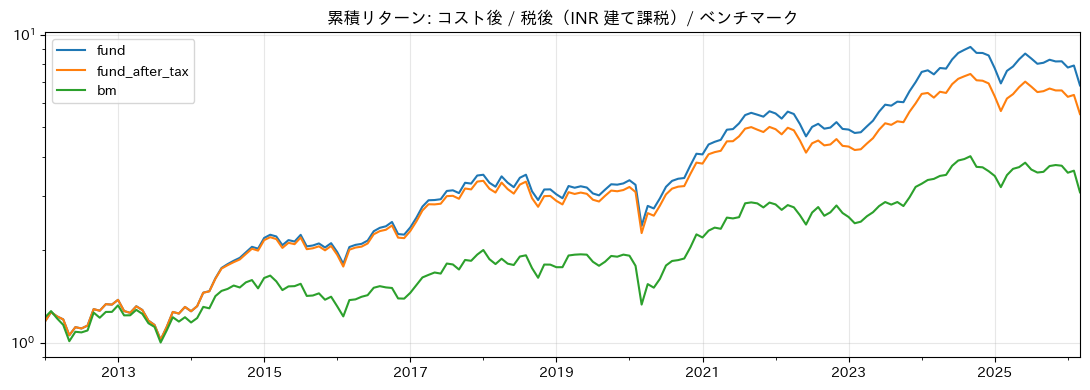

In [15]:
ax = (1 + tax_inr[["fund", "fund_after_tax", "bm"]]).cumprod().plot(figsize=(11, 4), logy=True)
ax.set_title("累積リターン: コスト後 / 税後（INR 建て課税）/ ベンチマーク")
plt.tight_layout()
plt.show()

## 9. 参照: 制約なしの分位ポートフォリオとの比較

最適化に使ったアルファ（`composite/comp_ew`）で単純に Q5（最上位 20%）を等ウェイト / 時価総額ウェイトで保有した場合
（`alphaeval.quantile_analysis`、コスト前）と、最適化後ポートフォリオ（コスト前の超過）を並べる。
最適化が制約（TE 目標、業種 ±3%、個別 ±3% など）の下でどれだけアルファを実現できているかの目安になる。

In [16]:
start, end = out.rebalance_dates.min(), out.rebalance_dates.max()
univ = store.universe(start, end)
bm_w = store.benchmark(BENCHMARK, start, end)
score = store.alpha(SCORE_USED, start, end)
rtn_usd = store.returns(RISK_MODEL, "rtn_usd", start, None)
bm_ret = portfolio_returns(bm_w, rtn_usd)

rows = {}
for label, scheme in [("Q5 等ウェイト", "equal"), ("Q5 時価総額", "size")]:
    q = quantile_analysis(score, rtn_usd, univ, n_quantiles=5, scheme=scheme, higher_is_better=True)
    r = q.returns["Q1"]
    s = performance_summary(r, bm_ret.reindex(r.index), q.turnover["Q1"])
    rows[label] = {"超過（コスト前）": s["active_return"], "TE": s["tracking_error"], "IR": s["information_ratio"], "年率回転率": s["turnover_annual"], "平均銘柄数": q.n_holdings["Q1"].mean()}
t = res.table.dropna(subset=["fund"])
s = performance_summary(t["bm"] + t["excess_gross"], t["bm"], t["turnover"])
rows["最適化（コスト前）"] = {"超過（コスト前）": s["active_return"], "TE": s["tracking_error"], "IR": s["information_ratio"], "年率回転率": s["turnover_annual"], "平均銘柄数": t["n_hold"].mean()}
rows["最適化（コスト後）"] = {"超過（コスト前）": res.summary["active_return"], "TE": res.summary["tracking_error"], "IR": res.summary["information_ratio"], "年率回転率": res.summary["turnover_annual"], "平均銘柄数": t["n_hold"].mean()}
display(pd.DataFrame(rows).T.round(3))

,超過（コスト前）,TE,IR,年率回転率,平均銘柄数
Q5 等ウェイト,0.124,0.111,1.111,3.991,77.005
Q5 時価総額,0.075,0.097,0.774,4.391,77.005
最適化（コスト前）,0.067,0.062,1.081,1.089,86.736
最適化（コスト後）,0.057,0.062,0.923,1.089,86.736


## 10. 補足

- 参照戦略の分位は `alphaeval` の規約で Q1 が最上位（`higher_is_better=True`）。合成スコアの仕様書（Q5 = 最上位）とは番号が逆なので注意。
- `A` ファイルの `sum_pos_w` 等は % のまま（ウェイト合計）。`exposures()` は値をそのまま返す。
- 税評価は `O` の `wgt_o` を毎月のリバランス後ウェイトとみなす。bax の微小株数（`op` に残る 0.01% 未満のポジション）は `O` に載らないため無視される。
- `after_tax` の `burn_in` は、初期構築の全ロットが同一取得日になる初期化バイアスを避けるためのもの。